## Klasifikasi 


### Import Library

In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import os
import warnings
import urllib.request

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
import mysql.connector

# Supress warnings supaya output lebih bersih
warnings.filterwarnings('ignore')

print("Semua library berhasil diimpor!")


Semua library berhasil diimpor!


### Load Dataset 

In [2]:
import pandas as pd
import mysql.connector

print("=== MEMUAT DATASET E.COLI ===")

# Fungsi untuk load data dari MySQL
def load_mysql():
    try:
        conn_params = {
            'user': 'root', 'password': '', 'host': 'localhost',
            'database': 'ecoli', 'port': 3306
        }
        conn = mysql.connector.connect(**conn_params)
        df_local = pd.read_sql("SELECT * FROM ecoli", conn)
        conn.close()
        print("Data berhasil dimuat dari MySQL")
        return df_local
    except Exception as e:
        print("Gagal memuat dari MySQL:", e)
        return None

# Coba load dari MySQL
df = load_mysql()

# Jika MySQL gagal, ambil dari UCI repository
if df is None:
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/ecoli/ecoli.data"
    cols = ['protein_name', 'mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2', 'location_class']
    df = pd.read_csv(url, delimiter='\s+', names=cols)
    print("Data berhasil dimuat dari UCI repository")

# Info awal dataset
print(f"\nShape dataset: {df.shape}")
print(f"Kelas target: {df['location_class'].unique()}")
print("\n5 baris pertama:\n", df.head())


=== MEMUAT DATASET E.COLI ===
Gagal memuat dari MySQL: 2003 (HY000): Can't connect to MySQL server on 'localhost:3306' (111)
Data berhasil dimuat dari UCI repository

Shape dataset: (336, 9)
Kelas target: ['cp' 'im' 'imS' 'imL' 'imU' 'om' 'omL' 'pp']

5 baris pertama:
   protein_name   mcg   gvh   lip  chg   aac  alm1  alm2 location_class
0    AAT_ECOLI  0.49  0.29  0.48  0.5  0.56  0.24  0.35             cp
1   ACEA_ECOLI  0.07  0.40  0.48  0.5  0.54  0.35  0.44             cp
2   ACEK_ECOLI  0.56  0.40  0.48  0.5  0.49  0.37  0.46             cp
3   ACKA_ECOLI  0.59  0.49  0.48  0.5  0.52  0.45  0.36             cp
4    ADI_ECOLI  0.23  0.32  0.48  0.5  0.55  0.25  0.35             cp


### Prepocesing

In [3]:
# ==================================================
# PREPROCESSING
# ==================================================
from sklearn.preprocessing import StandardScaler, LabelEncoder

print("=== MEMULAI PREPROCESSING DATA ===")
print()

# Pisahkan fitur dan target
X_df = df.drop(columns=['protein_name', 'location_class'])  # semua kolom kecuali target
y = df['location_class']

# Encode target ke bentuk numerik
le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"Label unik: {le.classes_}")
print(f"Label encoded: {np.unique(y_enc)}")
print()

# Pastikan semua fitur berupa string jika ada list/array, lalu one-hot encode
X_df = X_df.applymap(lambda x: str(x) if isinstance(x, (list, np.ndarray)) else x)
X_encoded = pd.get_dummies(X_df, drop_first=True)
print(f"Shape fitur setelah one-hot encoding: {X_encoded.shape}")
print()

# Scaling fitur numerik
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Preprocessing selesai. Contoh 5 baris pertama fitur setelah scaling:")
print(X_scaled[:5])


=== MEMULAI PREPROCESSING DATA ===

Label unik: ['cp' 'im' 'imL' 'imS' 'imU' 'om' 'omL' 'pp']
Label encoded: [0 1 2 3 4 5 6 7]

Shape fitur setelah one-hot encoding: (336, 7)

Preprocessing selesai. Contoh 5 baris pertama fitur setelah scaling:
[[-0.0517614  -1.41953086 -0.17514236 -0.05463584  0.49078096 -1.20771743
  -0.7160837 ]
 [-2.21287637 -0.67596708 -0.17514236 -0.05463584  0.32710612 -0.69711074
  -0.28566488]
 [ 0.30842443 -0.67596708 -0.17514236 -0.05463584 -0.08208098 -0.60427317
  -0.19001625]
 [ 0.46278978 -0.06759671 -0.17514236 -0.05463584  0.16343128 -0.23292285
  -0.66825939]
 [-1.38959448 -1.21674074 -0.17514236 -0.05463584  0.40894354 -1.16129864
  -0.7160837 ]]


### Distribusi Kelas Target

=== DISTRIBUSI KELAS TARGET ===

Distribusi kelas (original):
location_class
cp     143
im      77
imL      2
imS      2
imU     35
om      20
omL      5
pp      52
Name: count, dtype: int64


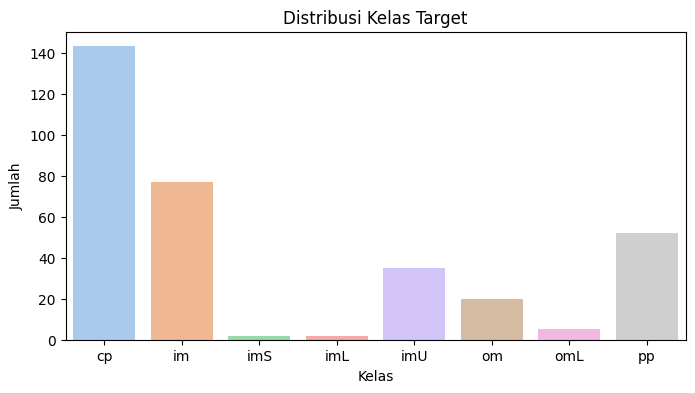

In [4]:
# ==================================================
# DISTRIBUSI KELAS TARGET
# ==================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("=== DISTRIBUSI KELAS TARGET ===")

# Jika y masih berupa Series string
y_series = pd.Series(y)
print("\nDistribusi kelas (original):")
print(y_series.value_counts().sort_index())

# Visualisasi dengan barplot
plt.figure(figsize=(8,4))
sns.countplot(x=y_series, palette="pastel")
plt.title("Distribusi Kelas Target")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.show()


### Balancing Dengan SMOTE

=== DATA BALANCING DENGAN SMOTE ===
Data asli:
location_class
cp     143
im      77
imL      2
imS      2
imU     35
om      20
omL      5
pp      52
Name: count, dtype: int64

Data setelah SMOTE:
location_class
cp     143
im     143
imL    143
imS    143
imU    143
om     143
omL    143
pp     143
Name: count, dtype: int64

Ringkasan:
• Data asli: 336 sampel
• Data setelah SMOTE: 1144 sampel
• Data yang di-generate: 808 sampel
Selesai!


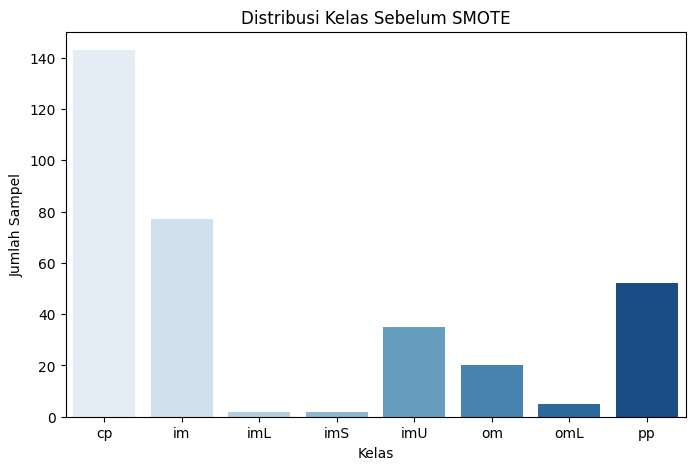

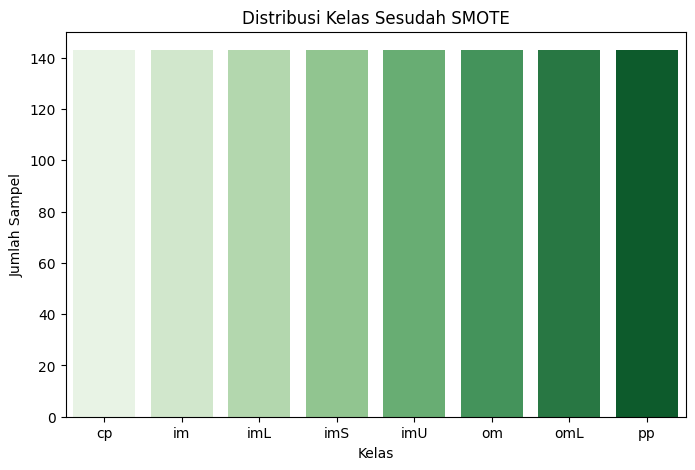

In [5]:
from imblearn.over_sampling import SMOTE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=== DATA BALANCING DENGAN SMOTE ===")

# Data asli
original_dist = pd.Series(y).value_counts().sort_index()
print("Data asli:")
print(original_dist)

# SMOTE (k=1 aman untuk kelas minoritas sangat sedikit)
smote = SMOTE(random_state=42, k_neighbors=1)
X_smote, y_smote = smote.fit_resample(X_scaled, y)

# Setelah SMOTE → konversi y_smote ke Series agar bisa value_counts
y_smote_series = pd.Series(y_smote)
smote_dist = y_smote_series.value_counts().sort_index()

print("\nData setelah SMOTE:")
print(smote_dist)

print("\nRingkasan:")
print(f"• Data asli: {len(y)} sampel")
print(f"• Data setelah SMOTE: {len(y_smote)} sampel")
print(f"• Data yang di-generate: {len(y_smote) - len(y)} sampel")
print("Selesai!")

# ========================================
# VISUALISASI DISTRIBUSI KELAS (TERPISAH)
# ========================================

# 1. Distribusi Sebelum SMOTE
plt.figure(figsize=(8,5))
sns.barplot(x=original_dist.index, y=original_dist.values, palette="Blues")
plt.title("Distribusi Kelas Sebelum SMOTE")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")
plt.show()

# 2. Distribusi Sesudah SMOTE
plt.figure(figsize=(8,5))
sns.barplot(x=smote_dist.index, y=smote_dist.values, palette="Greens")
plt.title("Distribusi Kelas Sesudah SMOTE")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")
plt.show()


### Klasifikasi Data Asli

In [25]:
#Klasifikasi DATA ASLI (SEBELUM BALANCING)
print("=== KLASIFIKASI : DATA ASLI ===")

# Split data untuk training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Training Naive Bayes
nb_original = GaussianNB()
nb_original.fit(X_train, y_train)
y_pred_original = nb_original.predict(X_test)

# Evaluasi
acc_original = accuracy_score(y_test, y_pred_original)
print(f"\nAccuracy (Data Asli): {acc_original:.4f}")

print("\nClassification Report (Data Asli):")
print(classification_report(y_test, y_pred_original))

=== KLASIFIKASI : DATA ASLI ===
Training set: 235 samples
Test set: 101 samples

Accuracy (Data Asli): 0.7822

Classification Report (Data Asli):
              precision    recall  f1-score   support

          cp       0.91      1.00      0.96        43
          im       0.78      0.61      0.68        23
         imL       0.00      0.00      0.00         1
         imS       0.00      0.00      0.00         1
         imU       0.62      0.50      0.56        10
          om       0.00      0.00      0.00         6
         omL       0.50      1.00      0.67         1
          pp       0.62      1.00      0.76        16

    accuracy                           0.78       101
   macro avg       0.43      0.51      0.45       101
weighted avg       0.73      0.78      0.74       101



### Klasifikasi Dengan Naive Bayes, Random Forest Dan Bagging Classifier

In [14]:
def train_evaluate(X, y, title="Dataset"):
    from sklearn.naive_bayes import GaussianNB
    from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
    from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    print(f"\n=== KLASIFIKASI: {title} ===")

    # Naive Bayes
    nb = GaussianNB()
    nb.fit(X, y)
    y_pred_nb = nb.predict(X)
    print("\n--- Naive Bayes ---")
    print("Accuracy:", round(accuracy_score(y, y_pred_nb), 4))
    print(classification_report(y, y_pred_nb))

    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y, y_pred_nb), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - Naive Bayes ({title})")
    plt.show()

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)
    y_pred_rf = rf.predict(X)
    print("\n--- Random Forest ---")
    print("Accuracy:", round(accuracy_score(y, y_pred_rf), 4))
    print(classification_report(y, y_pred_rf))

    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y, y_pred_rf), annot=True, fmt="d", cmap="Greens")
    plt.title(f"Confusion Matrix - Random Forest ({title})")
    plt.show()

    # Bagging Classifier (Random Forest base)
    bagging = BaggingClassifier(
        estimator=RandomForestClassifier(n_estimators=50, random_state=42),
        n_estimators=10,
        random_state=42
    )
    bagging.fit(X, y)
    y_pred_bagging = bagging.predict(X)
    print("\n--- Bagging Classifier ---")
    print("Accuracy:", round(accuracy_score(y, y_pred_bagging), 4))
    print(classification_report(y, y_pred_bagging))

    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y, y_pred_bagging), annot=True, fmt="d", cmap="Reds")
    plt.title(f"Confusion Matrix - Bagging ({title})")
    plt.show()


### Penampilan Data Asli


=== KLASIFIKASI: Data Asli ===

--- Naive Bayes ---
Accuracy: 0.7827
              precision    recall  f1-score   support

           0       0.90      0.97      0.94       143
           1       0.93      0.56      0.70        77
           2       1.00      1.00      1.00         2
           3       0.25      1.00      0.40         2
           4       0.69      0.57      0.62        35
           5       1.00      0.20      0.33        20
           6       1.00      1.00      1.00         5
           7       0.55      0.92      0.69        52

    accuracy                           0.78       336
   macro avg       0.79      0.78      0.71       336
weighted avg       0.84      0.78      0.77       336



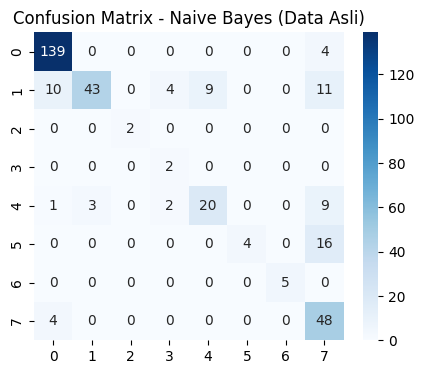


--- Random Forest ---
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       143
           1       1.00      1.00      1.00        77
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00        35
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00         5
           7       1.00      1.00      1.00        52

    accuracy                           1.00       336
   macro avg       1.00      1.00      1.00       336
weighted avg       1.00      1.00      1.00       336



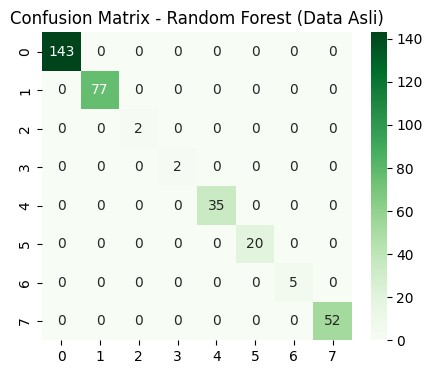


--- Bagging Classifier ---
Accuracy: 0.9762
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       143
           1       0.97      0.99      0.98        77
           2       1.00      1.00      1.00         2
           3       1.00      0.50      0.67         2
           4       1.00      0.94      0.97        35
           5       1.00      0.95      0.97        20
           6       1.00      1.00      1.00         5
           7       0.94      0.96      0.95        52

    accuracy                           0.98       336
   macro avg       0.99      0.92      0.94       336
weighted avg       0.98      0.98      0.98       336



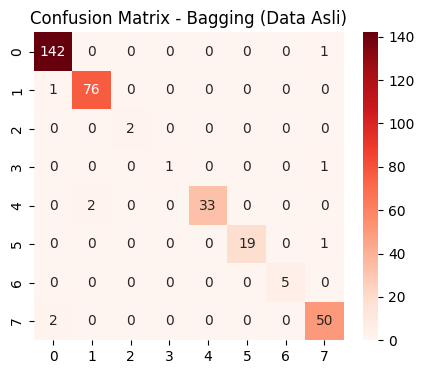

In [15]:
# Data asli
train_evaluate(X_scaled, y_enc, title="Data Asli")

### Penampilan Data Setelah SMOTE


=== KLASIFIKASI: Data SMOTE ===

--- Naive Bayes ---
Accuracy: 0.8392
              precision    recall  f1-score   support

          cp       0.86      0.97      0.91       143
          im       0.96      0.57      0.72       143
         imL       1.00      1.00      1.00       143
         imS       0.95      1.00      0.97       143
         imU       0.82      0.84      0.83       143
          om       1.00      0.38      0.55       143
         omL       1.00      1.00      1.00       143
          pp       0.53      0.95      0.68       143

    accuracy                           0.84      1144
   macro avg       0.89      0.84      0.83      1144
weighted avg       0.89      0.84      0.83      1144



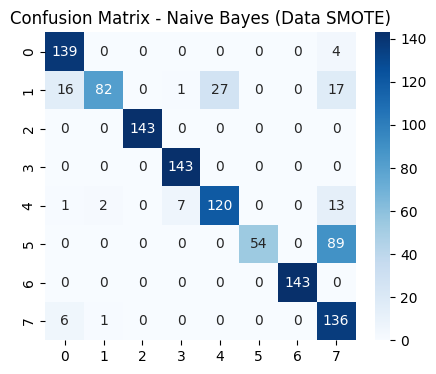


--- Random Forest ---
Accuracy: 1.0
              precision    recall  f1-score   support

          cp       1.00      1.00      1.00       143
          im       1.00      1.00      1.00       143
         imL       1.00      1.00      1.00       143
         imS       1.00      1.00      1.00       143
         imU       1.00      1.00      1.00       143
          om       1.00      1.00      1.00       143
         omL       1.00      1.00      1.00       143
          pp       1.00      1.00      1.00       143

    accuracy                           1.00      1144
   macro avg       1.00      1.00      1.00      1144
weighted avg       1.00      1.00      1.00      1144



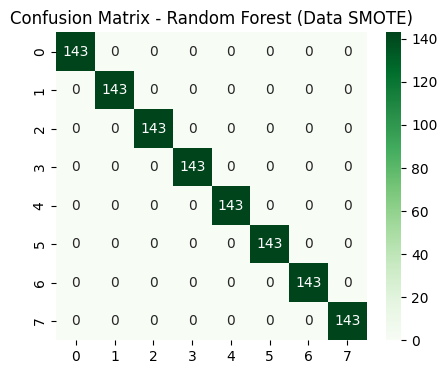


--- Bagging Classifier ---
Accuracy: 0.9921
              precision    recall  f1-score   support

          cp       0.99      0.99      0.99       143
          im       0.99      0.96      0.98       143
         imL       1.00      1.00      1.00       143
         imS       1.00      1.00      1.00       143
         imU       0.97      0.99      0.98       143
          om       1.00      0.99      1.00       143
         omL       1.00      1.00      1.00       143
          pp       0.99      1.00      0.99       143

    accuracy                           0.99      1144
   macro avg       0.99      0.99      0.99      1144
weighted avg       0.99      0.99      0.99      1144



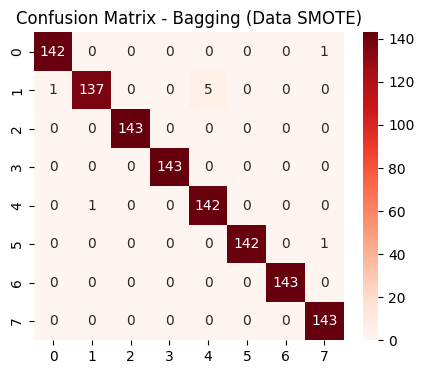

In [16]:
# Data SMOTE
train_evaluate(X_smote, y_smote, title="Data SMOTE")

### Perbandingan Performansi Model

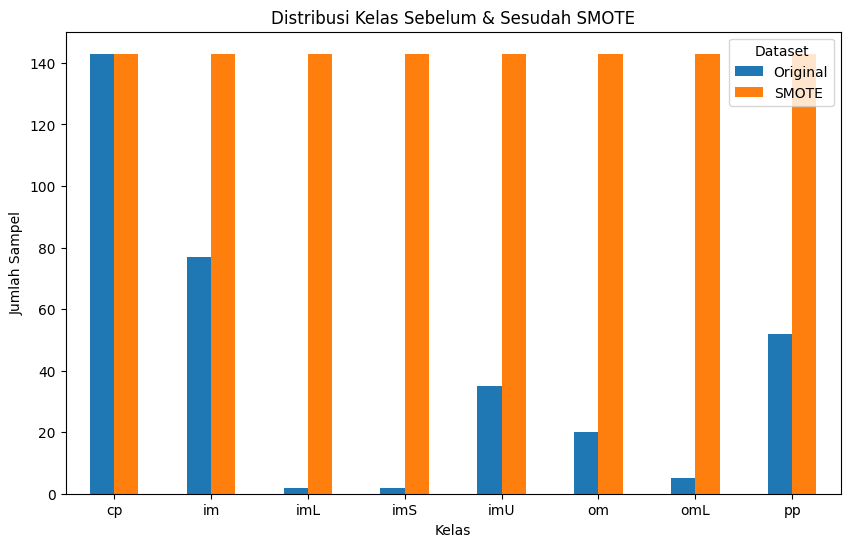

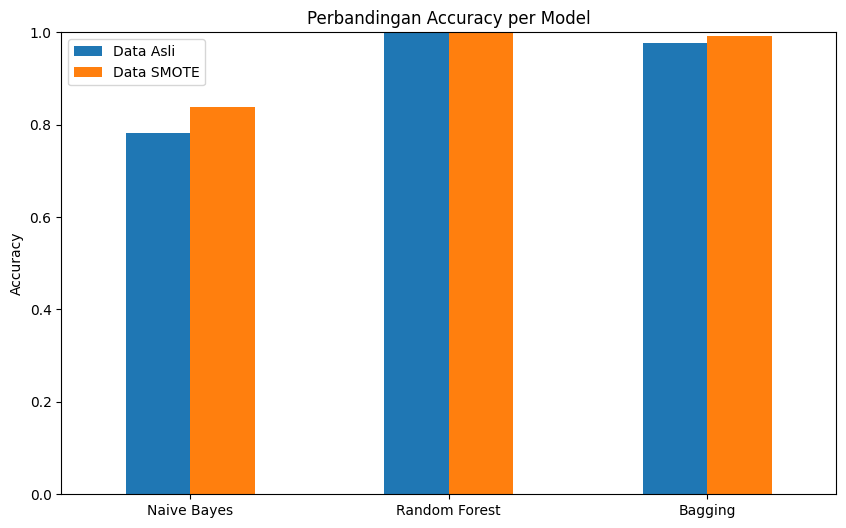

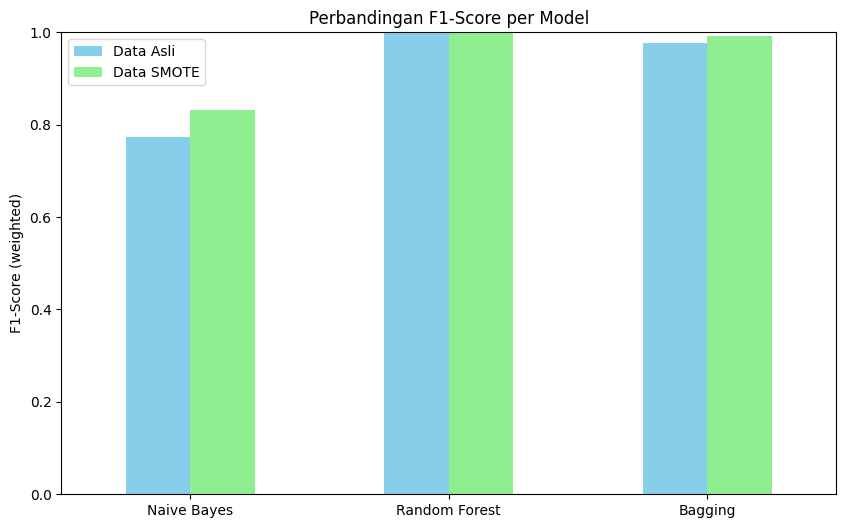

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

# ===============================
# Distribusi Kelas Sebelum & Sesudah SMOTE
# ===============================
original_dist = pd.Series(y).value_counts().sort_index()
smote_dist = pd.Series(y_smote).value_counts().sort_index()

dist_df = pd.DataFrame({
    'Original': original_dist,
    'SMOTE': smote_dist
}).fillna(0)

dist_df.plot(kind='bar', figsize=(10,6))
plt.title("Distribusi Kelas Sebelum & Sesudah SMOTE")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")
plt.xticks(rotation=0)
plt.legend(title="Dataset")
plt.show()

# ===============================
#  Perbandingan Performansi Model
# ===============================
def get_metrics(X, y):
    metrics = {}

    # Naive Bayes
    nb = GaussianNB()
    nb.fit(X, y)
    y_pred = nb.predict(X)
    metrics['Naive Bayes'] = {'accuracy': accuracy_score(y, y_pred),
                              'f1': f1_score(y, y_pred, average='weighted')}

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)
    y_pred = rf.predict(X)
    metrics['Random Forest'] = {'accuracy': accuracy_score(y, y_pred),
                                'f1': f1_score(y, y_pred, average='weighted')}

    # Bagging
    bagging = BaggingClassifier(
        estimator=RandomForestClassifier(n_estimators=50, random_state=42),
        n_estimators=10,
        random_state=42
    )
    bagging.fit(X, y)
    y_pred = bagging.predict(X)
    metrics['Bagging'] = {'accuracy': accuracy_score(y, y_pred),
                          'f1': f1_score(y, y_pred, average='weighted')}

    return metrics

# Hitung metrics
results_asli = get_metrics(X_scaled, y_enc)
results_smote = get_metrics(X_smote, y_smote)

# Buat DataFrame untuk plotting
df_acc = pd.DataFrame({
    'Data Asli': {model: results_asli[model]['accuracy'] for model in results_asli},
    'Data SMOTE': {model: results_smote[model]['accuracy'] for model in results_smote}
})

df_f1 = pd.DataFrame({
    'Data Asli': {model: results_asli[model]['f1'] for model in results_asli},
    'Data SMOTE': {model: results_smote[model]['f1'] for model in results_smote}
})

# Plot Accuracy
df_acc.plot(kind='bar', figsize=(10,6))
plt.title("Perbandingan Accuracy per Model")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.show()

# Plot F1-Score
df_f1.plot(kind='bar', figsize=(10,6), color=['skyblue','lightgreen'])
plt.title("Perbandingan F1-Score per Model")
plt.ylabel("F1-Score (weighted)")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.show()
